# 07 — Interpretation, Risk Segmentation, Retention Simulation

**Goal:** explain *why* the model predicts what it predicts (globally and per customer), turn
probabilities into an operational risk-tier system, and simulate model-driven retention
targeting under explicit, adjustable assumptions.

**Vocabulary discipline, fixed up front** — three different things that are easy to blur:

- **Correlation / association** — what EDA and the statistical tests measured.
- **Predictive importance** — how much the *model* leans on a feature. Not the same thing:
  correlated features share importance in model-dependent ways.
- **Causation** — established by none of the above. Nothing in this notebook says "changing X
  will change churn"; interventions derived here are *hypotheses to A/B test*.

*Note on data usage:* the test set is used here for reporting-only purposes (importances,
segment statistics, simulation curves). No decision feeds back into the model — the model and
threshold were frozen in notebook 06.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import DECISION_THRESHOLD, FIGURES_DIR, FINAL_MODEL_FILE, RANDOM_STATE
from src.feature_engineering import FEATURES_DATA_FILE
from src.train import split_data

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID, BASE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": BASE, "axes.labelcolor": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "bold", "figure.dpi": 110,
})

bundle = joblib.load(FINAL_MODEL_FILE)
pipe, threshold = bundle["pipeline"], bundle["threshold"]
df = pd.read_csv(FEATURES_DATA_FILE)
X_train, X_test, y_train, y_test = split_data(df)

pre = pipe.named_steps["preprocess"]
lr = pipe.named_steps["model"]
feat_names = pre.get_feature_names_out()
proba = pipe.predict_proba(X_test)[:, 1]
print(f"model loaded | threshold={threshold} | {len(feat_names)} model inputs")

model loaded | threshold=0.3379455021023619 | 33 model inputs


## 1. Logistic regression coefficients — with the honesty caveat attached

Coefficients are **log-odds effects, conditional on every other feature being held fixed** —
which, with correlated features, makes individual coefficients within a correlated group
treacherous to read alone. Two live examples from our own model, worth understanding deeply:

- **`MonthlyCharges` has a *negative* coefficient (−0.21)** even though churners pay more on
  average (notebook 03). No contradiction: the service mix (fiber, streaming) already encodes
  *why* bills are high. Conditional on identical services, a higher residual price associates
  with *lower* churn (plausibly premium/bundled customers). The marginal association and the
  conditional effect answer different questions — knowing which one you're reading is the skill.
- **`PaymentMethod_Electronic check` sits at ≈ 0.005** — not because e-check doesn't matter,
  but because the engineered `auto_pay` feature (−0.24) absorbed the signal. Regularization
  splits weight arbitrarily within collinear groups.

So: read coefficients for *direction and rough magnitude within uncorrelated features*, and use
permutation importance (§2) for the question "which raw attribute matters".

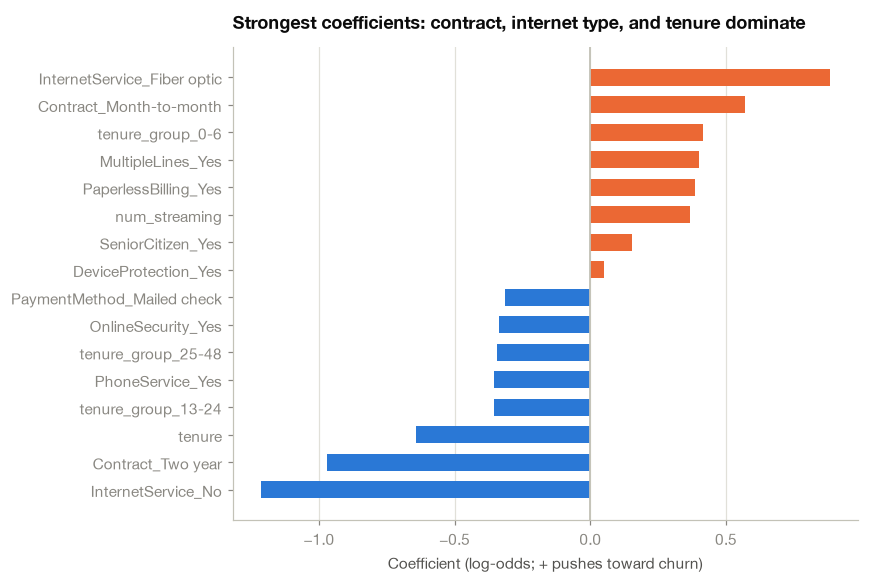

Odds-ratio examples:
  InternetService_Fiber optic: coef +0.882 -> odds x2.41
  Contract_Month-to-month: coef +0.571 -> odds x1.77
  tenure: coef -0.643 -> odds x0.53 (per +1 SD = 24.6 months)
  InternetService_No: coef -1.213 -> odds x0.30


In [2]:
coefs = pd.Series(lr.coef_[0], index=feat_names).sort_values()
top = pd.concat([coefs.head(8), coefs.tail(8)])
fig, ax = plt.subplots(figsize=(8, 5.4))
colors = [BLUE if v < 0 else ORANGE for v in top]
ax.barh(top.index, top.values, color=colors, height=0.62)
ax.axvline(0, color=BASE, lw=1.2)
ax.set_xlabel("Coefficient (log-odds; + pushes toward churn)")
ax.set_title("Strongest coefficients: contract, internet type, and tenure dominate", loc="left", pad=12)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "14_lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
print("Odds-ratio examples:")
for f in ["InternetService_Fiber optic", "Contract_Month-to-month", "tenure", "InternetService_No"]:
    print(f"  {f}: coef {coefs[f]:+.3f} -> odds x{np.exp(coefs[f]):.2f}"
          + (" (per +1 SD = 24.6 months)" if f == "tenure" else ""))

**Reading (with the multi-level caveat: for `InternetService` and `Contract`, compare levels
to each other):** fiber vs DSL is a +1.10 log-odds gap (odds ×3.0); month-to-month vs two-year
+1.54 (odds ×4.7); one standard deviation of tenure (~24.6 months) multiplies churn odds by
0.53. Protective add-ons (`OnlineSecurity_Yes` −0.34, `TechSupport_Yes` −0.29) reduce
conditional odds; streaming does not. Directionally identical to the EDA — the model found what
the analysis found, which is exactly what should happen.

## 2. Permutation importance — the cleaner global view

Shuffle one **raw input column** at a time (before preprocessing) and measure the test ROC-AUC
drop. Because it permutes raw columns, related one-hot levels move together, giving importance
per *business attribute*. Caveat that keeps us honest: correlated features (tenure ↔
tenure_group; PaymentMethod ↔ auto_pay) share importance — a low score means "the model has a
substitute available," not "this attribute is irrelevant".

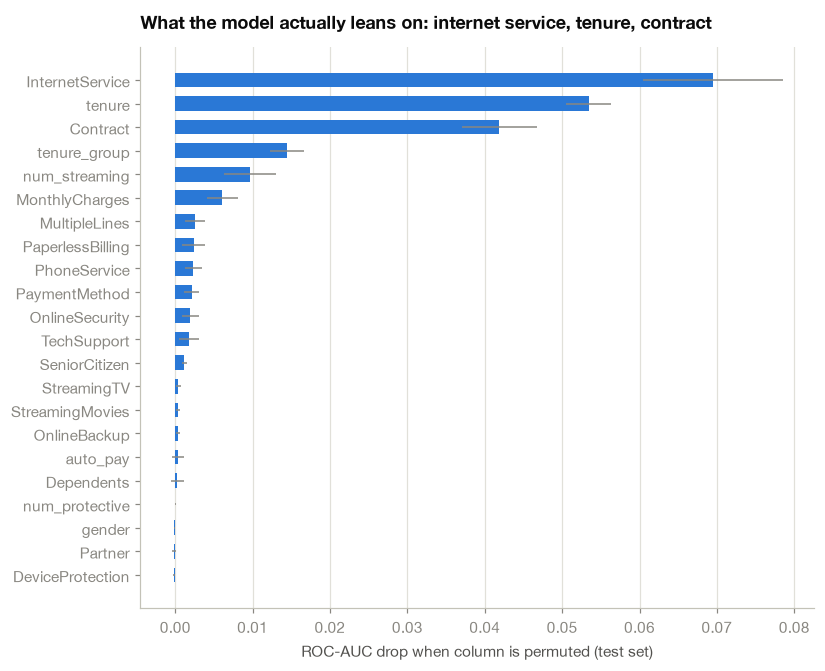

,auc_drop,std
InternetService,0.0695,0.0091
tenure,0.0534,0.0029
Contract,0.0419,0.0049
tenure_group,0.0144,0.0022
num_streaming,0.0097,0.0033
MonthlyCharges,0.0061,0.0020
MultipleLines,0.0026,0.0013
PaperlessBilling,0.0024,0.0015


In [3]:
from sklearn.inspection import permutation_importance

r = permutation_importance(pipe, X_test, y_test, scoring="roc_auc",
                           n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
pi = pd.DataFrame({"auc_drop": r.importances_mean, "std": r.importances_std},
                  index=X_test.columns).sort_values("auc_drop")

fig, ax = plt.subplots(figsize=(7.6, 6.2))
ax.barh(pi.index, pi["auc_drop"], xerr=pi["std"], color=BLUE, height=0.62,
        error_kw=dict(ecolor=MUTED, lw=1))
ax.set_xlabel("ROC-AUC drop when column is permuted (test set)")
ax.set_title("What the model actually leans on: internet service, tenure, contract", loc="left", pad=12)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "15_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()
pi.sort_values("auc_drop", ascending=False).head(8).round(4)

**Findings:** `InternetService` (−0.070 AUC when destroyed), `tenure` (−0.053), `Contract`
(−0.042) tower over everything else — the same top three as the Phase-4/5 effect-size hierarchy
(V = 0.32, r = 0.48, V = 0.41). **The pre-registered sanity check passes: `gender` sits at
−0.0001, statistically zero**, exactly as the χ² test (p = 0.49) predicted. `auto_pay` and
`num_protective` score ≈ 0 *because their raw source columns remain available as substitutes* —
the caveat above in action, not evidence the engineered features were useless (the linear model
used them: auto_pay carries −0.24 of the payment group's weight).

## 3. SHAP — additive per-customer explanations

For a linear model, SHAP values are exact and cheap (`LinearExplainer`): each customer's
prediction decomposes into per-feature contributions relative to the average customer. Global
beeswarm first, then individual explanations — this is the machinery the Streamlit app will
reuse to explain any prediction.

Background dataset has 5634 samples but max_samples=1000. Subsampling to 1000 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


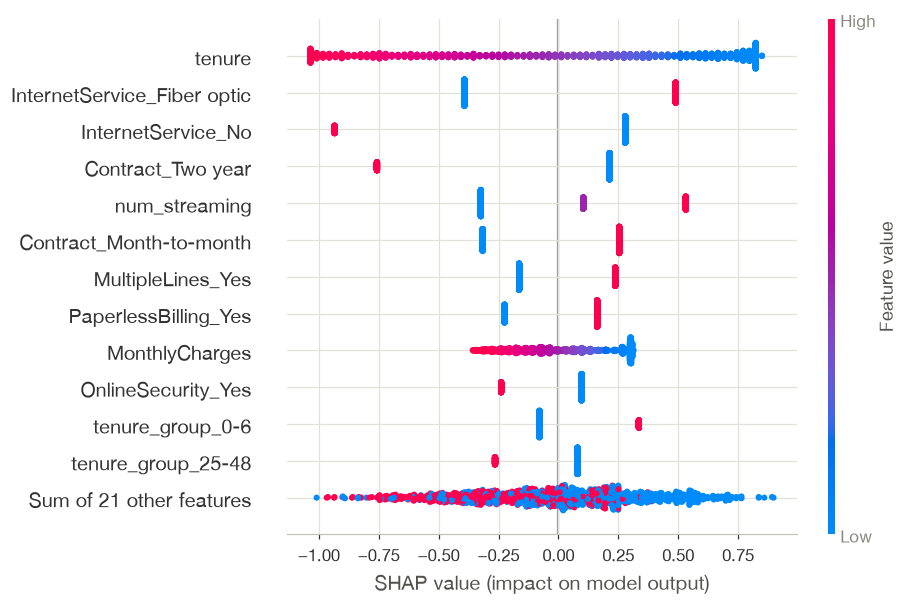

In [4]:
import shap

def to_dense(m):
    return np.asarray(m.toarray() if hasattr(m, "toarray") else m)

Xt_train = to_dense(pre.transform(X_train))
Xt_test = to_dense(pre.transform(X_test))
explainer = shap.Explainer(lr, shap.maskers.Independent(Xt_train, max_samples=1000),
                           feature_names=list(feat_names))
sv = explainer(Xt_test)
shap.plots.beeswarm(sv, max_display=13, show=False)
fig = plt.gcf(); fig.set_size_inches(8.6, 5.6); fig.tight_layout()
fig.savefig(FIGURES_DIR / "16_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the beeswarm:** each dot is one test customer. `Contract_Month-to-month = 1`
pushes predictions up (red dots, right side); high `tenure` pushes strongly down; fiber pushes
up. Consistent with coefficients (as it must be for a linear model — SHAP here ≈ coefficient ×
(value − mean)), but now *quantified per customer*, which is what §4 uses.

## 4. Individual explanations — three archetypes from the test set

The highest-risk customer, the lowest-risk customer, and one sitting exactly at the decision
threshold. Wording is deliberately associative ("factors raising the score"), never causal.

In [5]:
hi, lo = int(np.argmax(proba)), int(np.argmin(proba))
border = int(np.argmin(np.abs(proba - threshold)))
show_cols = ["tenure", "Contract", "InternetService", "MonthlyCharges",
             "PaymentMethod", "num_protective", "SeniorCitizen"]

def explain(i, label):
    contrib = pd.Series(sv.values[i], index=feat_names)
    top_up = contrib.sort_values(ascending=False).head(3)
    top_down = contrib.sort_values().head(3)
    print(f"--- {label}: predicted churn probability {proba[i]:.1%} "
          f"(actual: {'churned' if y_test.values[i] else 'stayed'}) ---")
    print(X_test.iloc[i][show_cols].to_string())
    print("  raising the score: " + ", ".join(f"{k} ({v:+.2f})" for k, v in top_up.items()))
    print("  lowering the score: " + ", ".join(f"{k} ({v:+.2f})" for k, v in top_down.items()) + "\n")

explain(hi, "HIGHEST RISK")
explain(lo, "LOWEST RISK")
explain(border, "AT THE THRESHOLD")

--- HIGHEST RISK: predicted churn probability 90.8% (actual: churned) ---
tenure                            1
Contract             Month-to-month
InternetService         Fiber optic
MonthlyCharges                 95.1
PaymentMethod      Electronic check
num_protective                    0
SeniorCitizen                   Yes
  raising the score: tenure (+0.82), num_streaming (+0.53), InternetService_Fiber optic (+0.49)
  lowering the score: MonthlyCharges (-0.21), StreamingTV_Yes (-0.04), PhoneService_Yes (-0.03)

--- LOWEST RISK: predicted churn probability 0.4% (actual: stayed) ---
tenure                                    72
Contract                            Two year
InternetService                           No
MonthlyCharges                         19.55
PaymentMethod      Bank transfer (automatic)
num_protective                             0
SeniorCitizen                             No
  raising the score: MonthlyCharges (+0.31), OnlineSecurity_Yes (+0.10), TechSupport_Yes (+0.08

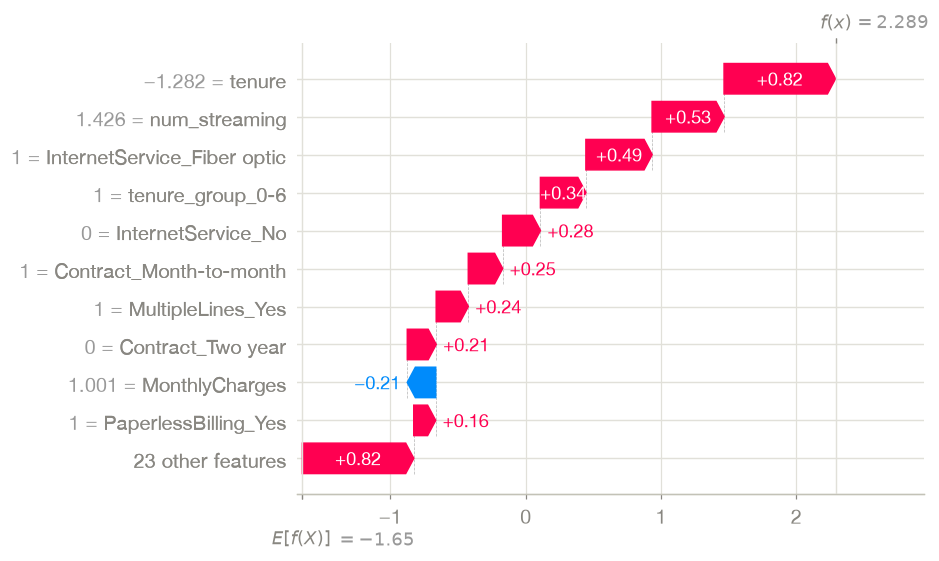

In [6]:
shap.plots.waterfall(sv[hi], max_display=11, show=False)
fig = plt.gcf(); fig.set_size_inches(8.6, 5.2); fig.tight_layout()
fig.savefig(FIGURES_DIR / "17_shap_waterfall_high_risk.png", dpi=150, bbox_inches="tight")
plt.show()

**The highest-risk customer (p = 0.91, did churn):** one month of tenure, month-to-month,
fiber at \$95.10, electronic check, zero protective add-ons, senior — every top EDA risk factor
at once; the waterfall shows one-month tenure, the streaming-without-protection service mix, and fiber doing most of the pushing.
**The lowest-risk customer (p = 0.4%, stayed):** 72 months tenure, two-year contract, no
internet, \$19.55, automatic bank transfer — the mirror image.
**The threshold customer (p = 33.7%, stayed):** month-to-month fiber e-check at \$96.55 —
high-risk profile — but 20 months of tenure and **three protective add-ons** pull the score back
to the line. Exactly the kind of customer where a cheap intervention plausibly tips the balance,
and a concrete illustration of why per-customer explanations beat a global rule.

## 5. Customer risk segmentation

Tiers built from **model probabilities** with cutoffs anchored to decisions, not aesthetics:
**Low** < 0.338 (below the operating threshold — would not be flagged), **Medium** 0.338–0.65
(flagged; standard retention motion), **High** ≥ 0.65 (probability exceeds even the top
calibration deciles' actual churn — priority outreach). Statistics computed on the held-out
test set, so the churn rates are honest out-of-sample numbers.

In [7]:
seg = pd.cut(proba, [0, threshold, 0.65, 1.0], labels=["Low", "Medium", "High"],
             include_lowest=True)
tdf = X_test.copy()
tdf["probability"], tdf["churned"], tdf["segment"] = proba, y_test.values, seg

profile = tdf.groupby("segment", observed=True).agg(
    customers=("churned", "count"),
    actual_churn_rate=("churned", "mean"),
    avg_predicted=("probability", "mean"),
    avg_monthly_charges=("MonthlyCharges", "mean"),
    avg_tenure_months=("tenure", "mean"),
    pct_month_to_month=("Contract", lambda s: (s == "Month-to-month").mean()),
    pct_fiber=("InternetService", lambda s: (s == "Fiber optic").mean()),
    pct_echeck=("PaymentMethod", lambda s: (s == "Electronic check").mean()),
)
for c in ["actual_churn_rate", "avg_predicted", "pct_month_to_month", "pct_fiber", "pct_echeck"]:
    profile[c] = (profile[c] * 100).round(1)
profile = profile.round(1)
churners = tdf.groupby("segment", observed=True)["churned"].sum()
print(f"churner capture: High {churners['High'] / tdf.churned.sum():.1%} | "
      f"High+Medium {(churners['High'] + churners['Medium']) / tdf.churned.sum():.1%}")
profile

churner capture: High 31.8% | High+Medium 73.0%


,customers,actual_churn_rate,avg_predicted,avg_monthly_charges,avg_tenure_months,pct_month_to_month,pct_fiber,pct_echeck
segment,,,,,,,,
Low,920,11.0,10.7,57.2,40.9,32.2,25.3,18.0
Medium,323,47.7,48.0,75.6,20.4,96.3,69.3,56.3
High,166,71.7,75.0,80.0,4.4,100.0,94.0,75.9


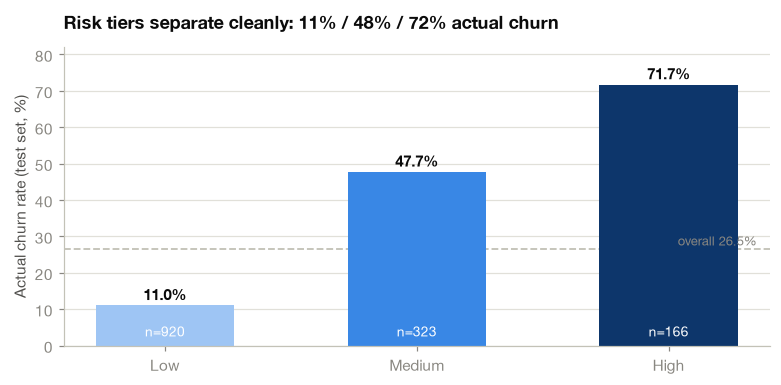

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 3.6))
rates = profile["actual_churn_rate"]
colors = ["#9ec5f4", "#3987e5", "#0d366b"]
bars = ax.bar(profile.index.astype(str), rates, color=colors, width=0.55)
ax.axhline(26.5, color=BASE, ls="--", lw=1.2, zorder=0)
ax.text(2.35, 27.5, "overall 26.5%", color=MUTED, fontsize=8.5, ha="right")
for b, r, n in zip(bars, rates, profile["customers"]):
    ax.text(b.get_x() + b.get_width() / 2, r + 1.5, f"{r:.1f}%", ha="center",
            color=INK, fontweight="bold")
    ax.text(b.get_x() + b.get_width() / 2, 2.5, f"n={n:,}", ha="center", color="white", fontsize=9)
ax.set_ylabel("Actual churn rate (test set, %)")
ax.set_ylim(0, 82)
ax.set_title("Risk tiers separate cleanly: 11% / 48% / 72% actual churn", loc="left", pad=12)
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "18_risk_segments.png", dpi=150, bbox_inches="tight")
plt.show()

**What distinguishes the segments** (from the profile table):

| | Low (n=920) | Medium (n=323) | High (n=166) |
|---|---|---|---|
| Actual churn | **11.0%** | **47.7%** | **71.7%** |
| Avg tenure | 40.9 mo | 20.4 mo | **4.4 mo** |
| Month-to-month | 32% | 96% | **100%** |
| Fiber | 25% | 69% | **94%** |
| E-check | 18% | 56% | **76%** |
| Avg bill | \$57 | \$76 | \$80 |

The High tier is a crisp operational object: **new month-to-month fiber customers paying by
e-check** — 12% of the base holding 32% of all churn. High+Medium (35% of customers) capture
**73% of churners**. The tiers are also *calibrated*: predicted averages (10%/50%/80%) track
actual rates (11%/48%/72%).

## 6. Retention-targeting simulation

**Scenario:** the retention team can contact the top X% of customers ranked by predicted churn
probability. Model-measured quantities (computable, no assumptions): customers contacted,
churners captured, recall, precision, and the annualized revenue of captured churners
(their `MonthlyCharges × 12` — the revenue *at stake*, not revenue saved).

In [9]:
order = np.argsort(-proba)
total_churners = int(y_test.sum())
rows = []
for x in [5, 10, 20, 30, 40, 50]:
    k = int(len(proba) * x / 100)
    idx = order[:k]
    tp = int(y_test.values[idx].sum())
    rev = float((X_test.iloc[idx]["MonthlyCharges"] * 12 * y_test.values[idx]).sum())
    rows.append({"top %": x, "contacted": k, "churners captured": tp,
                 "recall": round(tp / total_churners, 3), "precision": round(tp / k, 3),
                 "annualized revenue at stake ($)": round(rev)})
targeting = pd.DataFrame(rows).set_index("top %")
targeting

,contacted,churners captured,recall,precision,annualized revenue at stake ($)
top %,,,,,
5,70,57,0.152,0.814,56763
10,140,105,0.281,0.750,100720
20,281,186,0.497,0.662,174074
30,422,244,0.652,0.578,225849
40,563,292,0.781,0.519,266066
50,704,330,0.882,0.469,291609


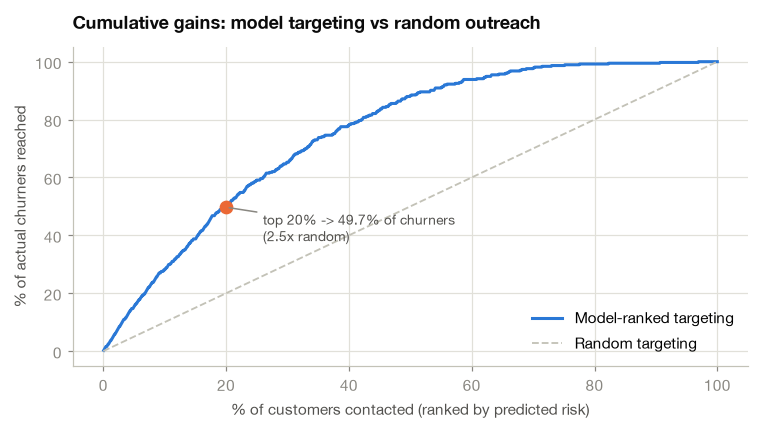

In [10]:
cum = np.cumsum(y_test.values[order]) / total_churners
pct = np.arange(1, len(cum) + 1) / len(cum) * 100
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pct, cum * 100, color=BLUE, lw=2, label="Model-ranked targeting")
ax.plot([0, 100], [0, 100], color=BASE, ls="--", lw=1.2, label="Random targeting")
ax.plot(20, 49.7, "o", color=ORANGE, ms=8)
ax.annotate("top 20% -> 49.7% of churners\n(2.5x random)", (20, 49.7), (26, 38),
            color=INK2, fontsize=9, arrowprops=dict(arrowstyle="-", color=MUTED, lw=1))
ax.set_xlabel("% of customers contacted (ranked by predicted risk)")
ax.set_ylabel("% of actual churners reached")
ax.set_title("Cumulative gains: model targeting vs random outreach", loc="left", pad=12)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "19_gains_curve.png", dpi=150, bbox_inches="tight")
plt.show()

**Model-measured result:** contacting the model's top 20% reaches **49.7% of all actual
churners** (precision 0.662) — **2.5× what random outreach achieves** at the same budget; the
top 5% runs at 81% precision. That multiplier *is* the business value of the model, and it
requires no assumptions.

### Financial scenario — assumptions explicit and adjustable

What the dataset does **not** contain: offer costs, intervention success rates, margins. So the
financial layer is a labeled scenario, with formulas shown and every parameter adjustable:

- `expected_retained = churners_captured × success_rate`
- `revenue_preserved = annualized_revenue_at_stake × success_rate` (upper bound: assumes a full
  extra year for retained customers)
- `program_cost = contacted × offer_cost`

**ASSUMPTIONS (illustrative, not data):** `success_rate = 30%`, `offer_cost = $50`.

In [11]:
SUCCESS_RATE = 0.30   # ASSUMPTION - fraction of contacted true churners the offer retains
OFFER_COST = 50.0     # ASSUMPTION - cost per contacted customer, $

scen = targeting.copy()
scen["expected retained"] = (scen["churners captured"] * SUCCESS_RATE).round(1)
scen["revenue preserved ($)"] = (scen["annualized revenue at stake ($)"] * SUCCESS_RATE).round(0)
scen["program cost ($)"] = (scen["contacted"] * OFFER_COST).round(0)
scen["scenario net ($)"] = (scen["revenue preserved ($)"] - scen["program cost ($)"]).round(0)
scen[["contacted", "churners captured", "expected retained",
      "revenue preserved ($)", "program cost ($)", "scenario net ($)"]]

,contacted,churners captured,expected retained,revenue preserved ($),program cost ($),scenario net ($)
top %,,,,,,
5,70,57,17.1,17029.0,3500.0,13529.0
10,140,105,31.5,30216.0,7000.0,23216.0
20,281,186,55.8,52222.0,14050.0,38172.0
30,422,244,73.2,67755.0,21100.0,46655.0
40,563,292,87.6,79820.0,28150.0,51670.0
50,704,330,99.0,87483.0,35200.0,52283.0


**Under these labeled assumptions**, every tier from top-5% to top-50% is scenario-positive,
with the largest net at the deeper tiers — but the *decision* (how deep to go) belongs to
whoever owns the real numbers; this table is a calculator, not a recommendation. What survives
any assumption change is the model-measured 2.5× capture multiplier: whatever an offer costs and
however often it works, ranked outreach reaches ~2.5× more churners per dollar than unranked.

## 7. Business recommendations

Evidence-based, association-worded, each with a testable intervention and a success metric.

**R1 — Early-lifecycle program for month-to-month fiber customers.**
*Observed:* this intersection churns at 54.6% (n=2,128, notebook 03); the High tier (72% actual
churn) averages 4.4 months tenure and is 100% month-to-month, 94% fiber.
*Test:* a first-90-days onboarding sequence plus a discounted 12-month conversion offer at
month 2–3, A/B against no-contact controls. *Measure:* 6-month churn, treatment vs control.

**R2 — Auto-pay migration campaign.**
*Observed:* e-check payers churn at 45.3% vs 15–17% for auto-pay; they are 34% of customers but
57% of churners. Selection effects are likely part of the association — hence a randomized test.
*Test:* small one-time credit for enrolling in auto-pay, randomized among e-check payers.
*Measure:* churn among enrolled vs control at 6 months (not enrollment rate alone).

**R3 — Attach protective add-ons where they're absent.**
*Observed:* internet customers without TechSupport/OnlineSecurity churn at ~42% vs ~15% with
them (V = 0.27 after removing structural effects); streaming add-ons show no such association —
so bundle *support*, not entertainment. *Test:* 3 free months of TechSupport+OnlineSecurity for
high-risk fiber customers. *Measure:* churn and post-trial paid retention vs control.

**R4 — Investigate the fiber experience itself.**
*Observed:* fiber churns at 2.2× DSL (41.9% vs 19.0%) at a \$35 higher median bill; the data
cannot separate price, service quality, and customer mix. *Action:* root-cause work (exit
surveys, complaint/outage overlays) before any blanket fiber discounting. *Measure:* fiber churn
by driver once instrumented.

**R5 — Deploy ranked outreach with a permanent holdout.**
*Observed:* top-20% targeting reaches 49.7% of churners at 66% precision (2.5× random).
*Action:* run all retention lists through the model; keep a never-contacted random holdout so
that *actual* retention lift (and the assumption table above) becomes measurable with real
numbers. *Measure:* churn delta vs holdout, per tier.
